In [1]:
# Clone the repository
!git clone https://github.com/phanindra-max/Cross-Generator-Generalization-Project.git

# Move into the directory
%cd Cross-Generator-Generalization-Project/

# Install dependencies if you have a requirements.txt
!pip install uv
!uv pip install -r requirements.txt

fatal: destination path 'Cross-Generator-Generalization-Project' already exists and is not an empty directory.
/content/Cross-Generator-Generalization-Project
Using Python 3.12.13 environment at: /usr
Checked 18 packages in 103ms


In [2]:
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

# Adjust this path if you keep the project elsewhere on Drive.
DRIVE_BACKUP = Path("/content/drive/MyDrive/deepfake-cross-generator/backups")
DRIVE_BACKUP.mkdir(parents=True, exist_ok=True)

# Source-of-truth list: every dataset artifact we want persisted.
ARTIFACTS = [
    ("data/real",           "real.tar",           "FFHQ thumbnails"),
    ("data/faceswap",       "faceswap.tar",       "FF++ FaceSwap frames"),
    ("data/diffusion_sd15", "diffusion_sd15.tar", "Stable Diffusion outputs"),
    ("data/splits",         "splits.tar",         "split manifest CSVs"),
]
print(f"Backup target: {DRIVE_BACKUP}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Backup target: /content/drive/MyDrive/deepfake-cross-generator/backups


# Data Pipeline: Deepfake Cross-Generator Detection

This notebook downloads and prepares all datasets for the project:
1. **FFHQ** (real faces) — 2000 thumbnails from HuggingFace
2. **FaceForensics++ FaceSwap c23** — 2000 frames from Kaggle
3. **Stable Diffusion v1.5** — 1000 generated portraits

Then creates reproducible CSV split manifests.

**Runtime**: Use a GPU runtime (T4 or better) for Stable Diffusion generation.

## 0. Install Dependencies

In [3]:
!uv pip install -q -r requirements.txt

In [4]:
import os
import sys
from pathlib import Path

# If running from notebooks/ directory, add project root to path
PROJECT_ROOT = Path(".").resolve().parent
if (PROJECT_ROOT / "src").exists():
    sys.path.insert(0, str(PROJECT_ROOT))
    os.chdir(PROJECT_ROOT)

print(f"Working directory: {os.getcwd()}")

Working directory: /content/Cross-Generator-Generalization-Project


## 1. Download FFHQ Real Faces (HuggingFace)

Downloads 2000 128x128 face thumbnails from the FFHQ dataset hosted on HuggingFace.

#### *Restore data from Drive (if available)

In [5]:
import subprocess, time
from pathlib import Path

def _is_empty(p: Path) -> bool:
    return (not p.exists()) or (not any(p.iterdir()))

def restore_one(local_dir: str, archive_name: str, label: str) -> bool:
    target = Path(local_dir)
    archive = DRIVE_BACKUP / archive_name
    if not _is_empty(target):
        print(f"  skip {label:<26} {local_dir} already populated")
        return True
    if not archive.exists():
        print(f"  miss {label:<26} no archive in Drive (pipeline will generate)")
        return False
    target.parent.mkdir(parents=True, exist_ok=True)
    t = time.time()
    subprocess.run(["tar", "-xf", str(archive), "-C", str(target.parent)], check=True)
    n_files = sum(1 for _ in target.iterdir())
    print(f"  ok   {label:<26} restored {n_files} files in {time.time()-t:.1f}s")
    return True

print("Restoring artifacts from Drive...")
restored = {label: restore_one(d, a, label) for d, a, label in ARTIFACTS}

# Final sanity check
print("\nLocal data tree:")
!ls data/ 2>/dev/null && echo "---" && for d in real faceswap diffusion_sd15 splits; do printf "%-20s %s files\n" "$d" "$(ls data/$d 2>/dev/null | wc -l)"; done

Restoring artifacts from Drive...
  skip FFHQ thumbnails            data/real already populated
  skip FF++ FaceSwap frames       data/faceswap already populated
  miss Stable Diffusion outputs   no archive in Drive (pipeline will generate)
  skip split manifest CSVs        data/splits already populated

Local data tree:
faceswap  real	splits
---
real                 2000 files
faceswap             382 files
diffusion_sd15       0 files
splits               0 files


In [6]:
from src.data.prepare_ffhq import download_ffhq

num_real = download_ffhq(
    output_dir="data/real",
    num_images=2000,
    resolution=128,
)
print(f"\nTotal real images: {num_real}")

Already have 2000 images in data/real, skipping download.

Total real images: 2000


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Download FaceForensics++ FaceSwap c23 (Kaggle)

Downloads the FF++ c23 dataset from Kaggle and extracts 4 evenly-spaced frames from 500 FaceSwap videos.

**Note**: You need Kaggle credentials configured. In Colab, run:
```python
from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
```
Or upload your `kaggle.json` to `~/.kaggle/kaggle.json`.

In [9]:
from src.data.prepare_faceforensics import prepare_faceforensics

num_faceswap = prepare_faceforensics(
    output_dir="data/faceswap",
    num_videos=500,
    frames_per_video=4,
    resolution=128,
)
print(f"\nTotal FaceSwap frames: {num_faceswap}")

Using Colab cache for faster access to the 'ff-c23' dataset.
Dataset downloaded to: /kaggle/input/ff-c23
Found FaceSwap directory: /kaggle/input/ff-c23/FaceForensics++_C23/FaceSwap
Found 1000 FaceSwap video files
Extracting frames with 11 parallel workers...


Extracting frames: 100%|██████████| 500/500 [02:10<00:00,  3.83it/s]

Done. Extracted 2000 frames to data/faceswap

Total FaceSwap frames: 2000


Backup files to Drive after step 1 and 2


In [10]:
# Backup files from drive
# from google.colab import drive
# drive.mount("/content/drive")

# from pathlib import Path
# DRIVE_BACKUP = Path("/content/drive/MyDrive/deepfake-cross-generator/backups")
# DRIVE_BACKUP.mkdir(parents=True, exist_ok=True)
# print(f"Backup target: {DRIVE_BACKUP}")

In [11]:
# import subprocess, time
# from pathlib import Path

# def backup_dir(local_dir: str, archive_name: str):
#     src = Path(local_dir)
#     if not src.exists() or not any(src.iterdir()):
#         print(f"Skip {local_dir}: empty or missing")
#         return
#     dest = DRIVE_BACKUP / archive_name
#     n_files = sum(1 for _ in src.glob("*"))
#     print(f"Archiving {n_files} files from {src} -> {dest} ...")
#     t = time.time()
#     # -C parents makes the archive contain only the leaf dir name (real/, faceswap/),
#     # so restore is path-agnostic.
#     subprocess.run(
#         ["tar", "-cf", str(dest), "-C", str(src.parent), src.name],
#         check=True,
#     )
#     size_mb = dest.stat().st_size / (1024 * 1024)
#     print(f"  {size_mb:.1f} MB in {time.time()-t:.1f}s")

# backup_dir("data/real", "real.tar")
# backup_dir("data/faceswap", "faceswap.tar")
# # Splits and diffusion outputs (run after step 3 if you want):
# # backup_dir("data/splits", "splits.tar")
# # backup_dir("data/diffusion_sd15", "diffusion_sd15.tar")
# print("\nDone. Files in Drive:")
# !ls -lh /content/drive/MyDrive/deepfake-cross-generator/backups/

## 3. Generate Stable Diffusion v1.5 Faces

Generates 1000 portrait images using 20 diverse prompts (50 images each).
Takes ~30 minutes on a T4 GPU.

In [13]:
from src.data.generate_diffusion import generate_diffusion_faces

num_diffusion = generate_diffusion_faces(
    output_dir="data/diffusion_sd15",
    num_images=1000,
    resolution=128,
    batch_size=64,
    seed=42,
)
print(f"\nTotal diffusion images: {num_diffusion}")

Loading Stable Diffusion pipeline: runwayml/stable-diffusion-v1-5


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Generating 1000 images (50 per prompt)...


Prompts:   0%|          | 0/20 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
Prompts: 100%|██████████| 20/20 [07:58<00:00, 23.92s/it]

Done. Generated 1000 images in data/diffusion_sd15

Total diffusion images: 1000


## 4. Create Split Manifests

Produces three CSV files with deterministic splits:
- `train.csv`: 1600 real + 1600 FaceSwap
- `test_indist.csv`: 400 real + 400 FaceSwap  
- `test_ood.csv`: 400 real + 1000 Stable Diffusion fakes

In [14]:
from src.data.create_splits import create_splits

train_df, test_indist_df, test_ood_df = create_splits(
    real_dir="data/real",
    faceswap_dir="data/faceswap",
    diffusion_dir="data/diffusion_sd15",
    output_dir="data/splits",
    seed=42,
)

Found 2000 real images
Found 2000 FaceSwap images
Found 1000 diffusion images

Split summary:
  train.csv:       3200 samples ({0: 1600, 1: 1600})
  test_indist.csv: 800 samples ({0: 400, 1: 400})
  test_ood.csv:    1400 samples ({1: 1000, 0: 400})


#### Save to Drive

In [15]:
import subprocess, time
from pathlib import Path

def backup_one(local_dir: str, archive_name: str, label: str):
    src = Path(local_dir)
    if not src.exists() or not any(src.iterdir()):
        print(f"  skip {label}: {local_dir} is empty/missing")
        return
    n_files = sum(1 for _ in src.iterdir())
    final = DRIVE_BACKUP / archive_name
    tmp = final.with_suffix(final.suffix + ".tmp")
    t = time.time()
    subprocess.run(
        ["tar", "-cf", str(tmp), "-C", str(src.parent), src.name],
        check=True,
    )
    tmp.replace(final)
    size_mb = final.stat().st_size / (1024 * 1024)
    print(f"  ok   {label:<26} {n_files:>5} files  {size_mb:>7.1f} MB  {time.time()-t:>5.1f}s")

print("Saving artifacts to Drive...")
for local_dir, archive_name, label in ARTIFACTS:
    backup_one(local_dir, archive_name, label)

print("\nDrive contents:")
!ls -lh /content/drive/MyDrive/deepfake-cross-generator/backups/

Saving artifacts to Drive...
  ok   FFHQ thumbnails             2000 files     62.2 MB    0.5s
  ok   FF++ FaceSwap frames        2000 files     62.3 MB    0.5s
  ok   Stable Diffusion outputs    1000 files     27.9 MB    0.2s
  ok   split manifest CSVs            4 files      0.2 MB    0.0s

Drive contents:
total 153M
-rw------- 1 root root  28M May  7 05:31 diffusion_sd15.tar
-rw------- 1 root root  63M May  7 05:31 faceswap.tar
-rw------- 1 root root  63M May  7 05:31 real.tar
-rw------- 1 root root 250K May  7 05:31 splits.tar


## 5. Verification & Sample Grid

In [16]:
import pandas as pd

print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

for split_name in ["train", "test_indist", "test_ood"]:
    df = pd.read_csv(f"data/splits/{split_name}.csv")
    print(f"\n{split_name}.csv: {len(df)} total samples")
    print(f"  By source: {df['source'].value_counts().to_dict()}")
    print(f"  By label:  {{0: 'real', 1: 'fake'}} -> {df['label'].value_counts().to_dict()}")

# Verify all files exist
all_dfs = pd.concat([train_df, test_indist_df, test_ood_df])
missing = [p for p in all_dfs["path"] if not Path(p).exists()]
if missing:
    print(f"\nWARNING: {len(missing)} files not found!")
    print(f"  First few: {missing[:5]}")
else:
    print(f"\nAll {len(all_dfs)} files verified to exist.")

DATASET SUMMARY

train.csv: 3200 total samples
  By source: {'ffhq': 1600, 'faceswap_c23': 1600}
  By label:  {0: 'real', 1: 'fake'} -> {0: 1600, 1: 1600}

test_indist.csv: 800 total samples
  By source: {'ffhq': 400, 'faceswap_c23': 400}
  By label:  {0: 'real', 1: 'fake'} -> {0: 400, 1: 400}

test_ood.csv: 1400 total samples
  By source: {'stable_diffusion_v1_5': 1000, 'ffhq': 400}
  By label:  {0: 'real', 1: 'fake'} -> {1: 1000, 0: 400}

All 5400 files verified to exist.


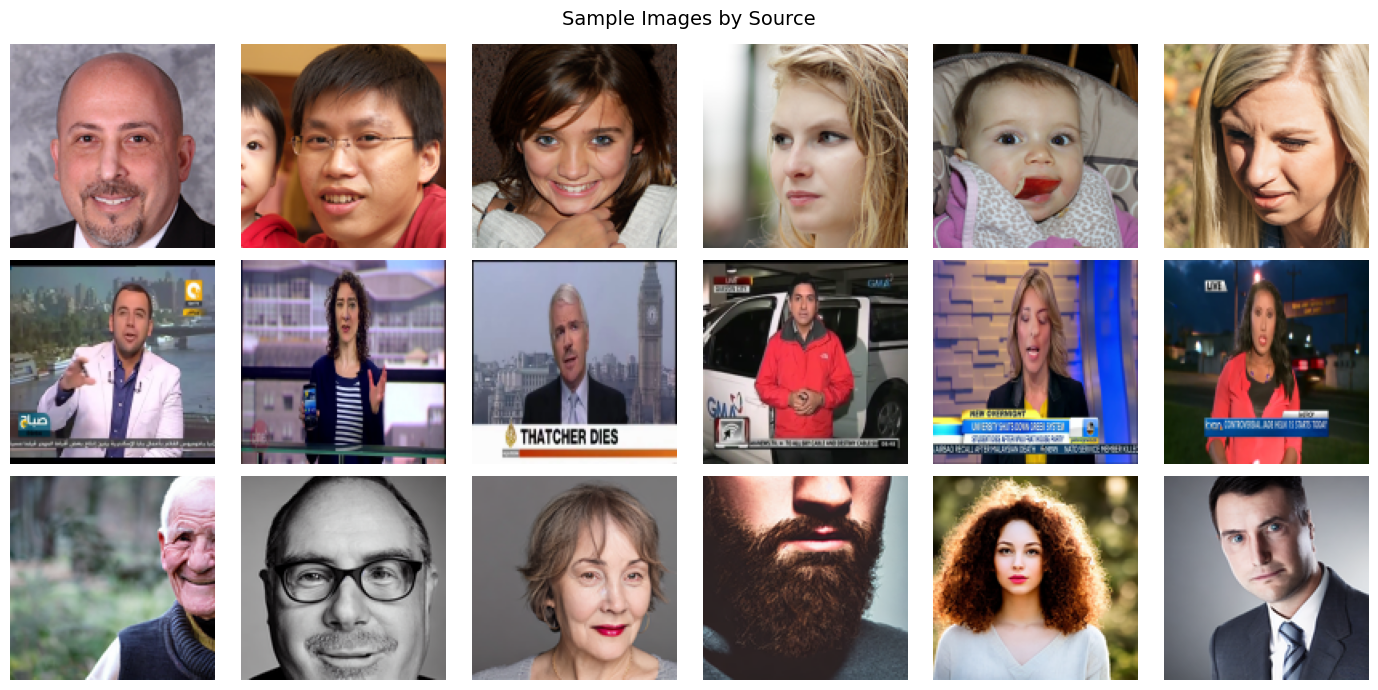

Sample grid saved to results/figures/data_samples.png


In [19]:
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
fig.suptitle("Sample Images by Source", fontsize=14)

sources = [("data/real", "Real (FFHQ)"), ("data/faceswap", "FaceSwap (FF++)"), ("data/diffusion_sd15", "Stable Diffusion")]

for row, (img_dir, title) in enumerate(sources):
    img_files = sorted(Path(img_dir).glob("*.png"))
    samples = random.sample(img_files, min(6, len(img_files)))

    for col, img_path in enumerate(samples):
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(title, fontsize=11, rotation=0, labelpad=80, va="center")

plt.tight_layout()
plt.savefig("results/figures/data_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sample grid saved to results/figures/data_samples.png")